=== Dataset Overview ===
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  

=== Dataset Information ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   sp

<Figure size 1500x1000 with 0 Axes>

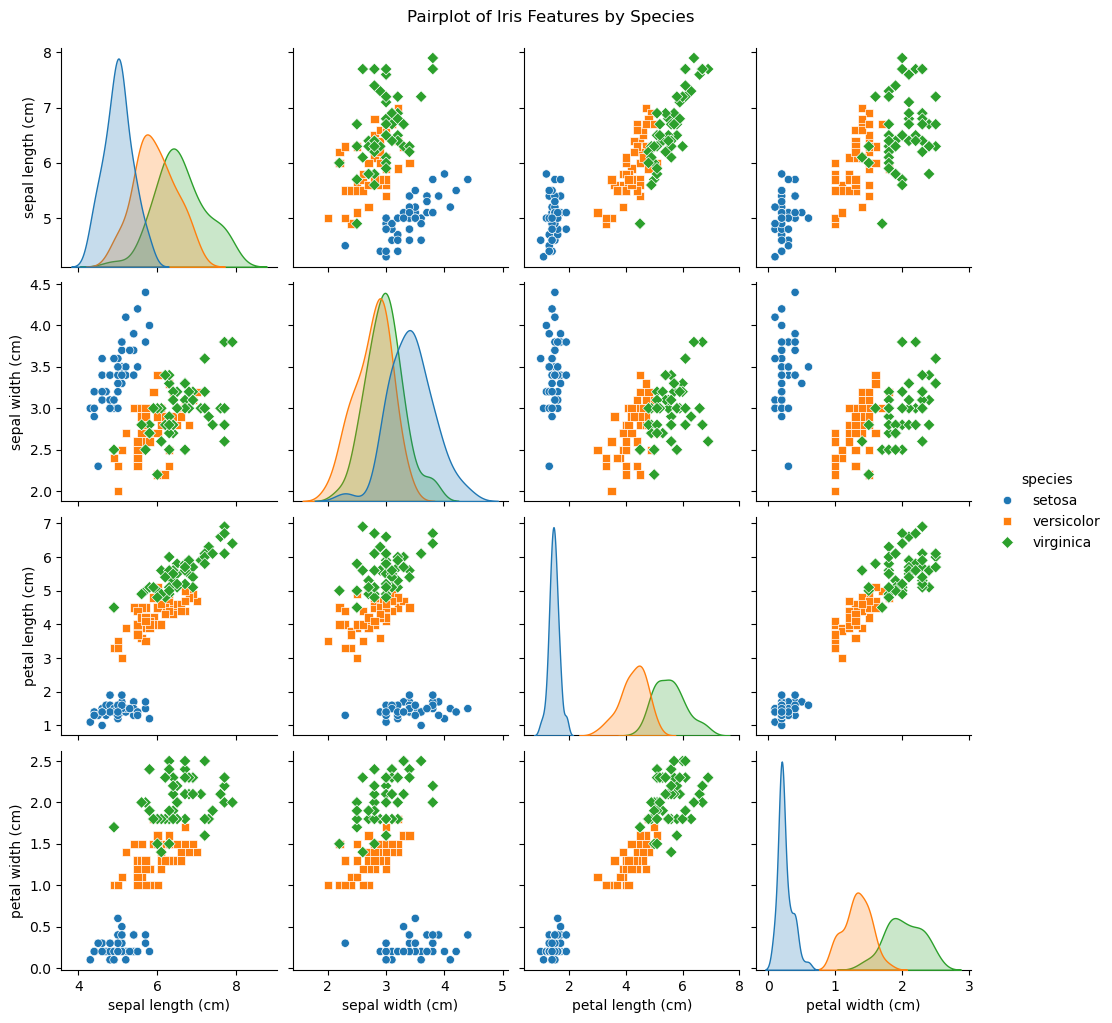

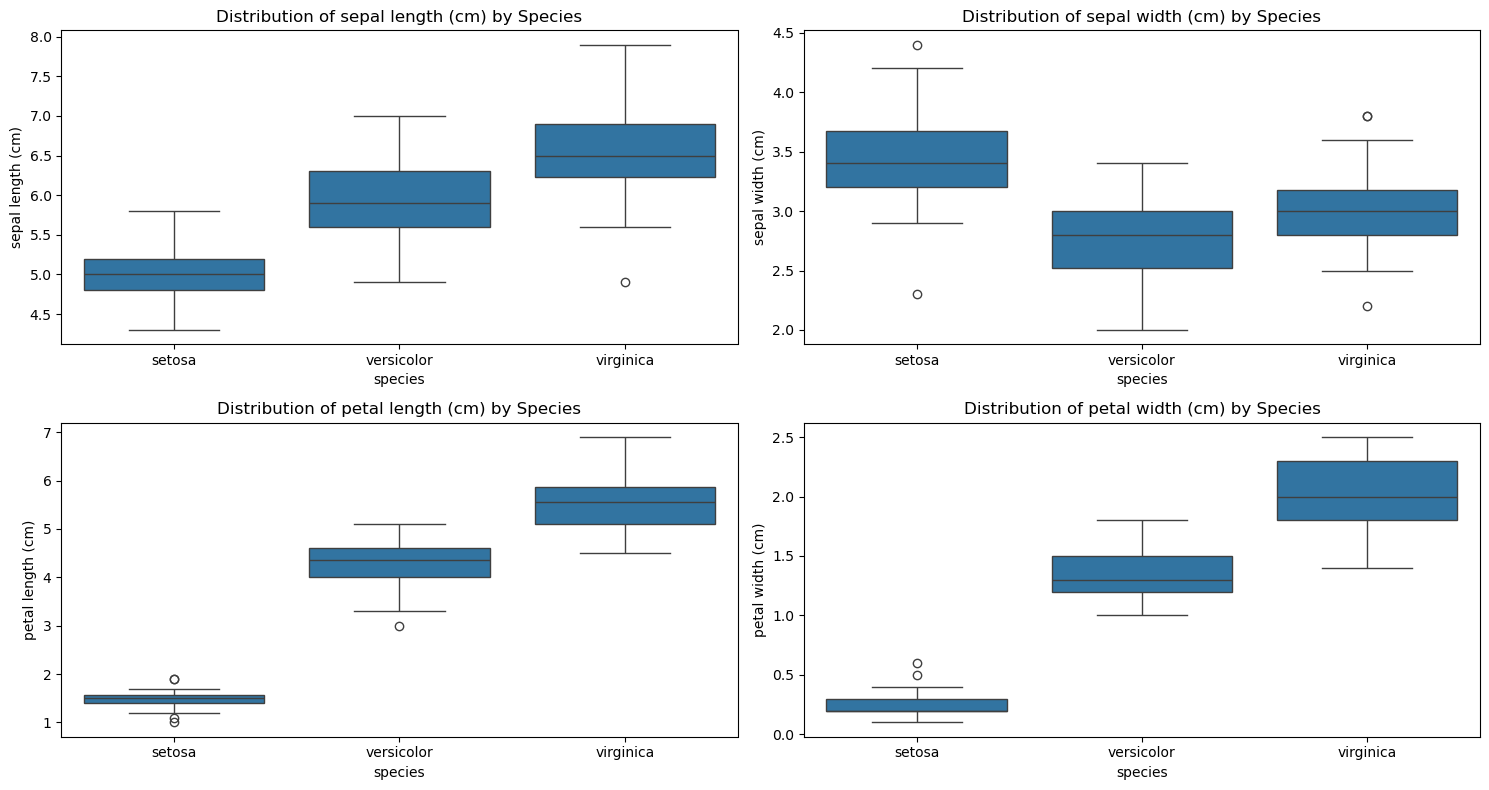


=== K-Nearest Neighbors Performance ===
Accuracy: 0.91

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.79      1.00      0.88        15
   virginica       1.00      0.73      0.85        15

    accuracy                           0.91        45
   macro avg       0.93      0.91      0.91        45
weighted avg       0.93      0.91      0.91        45



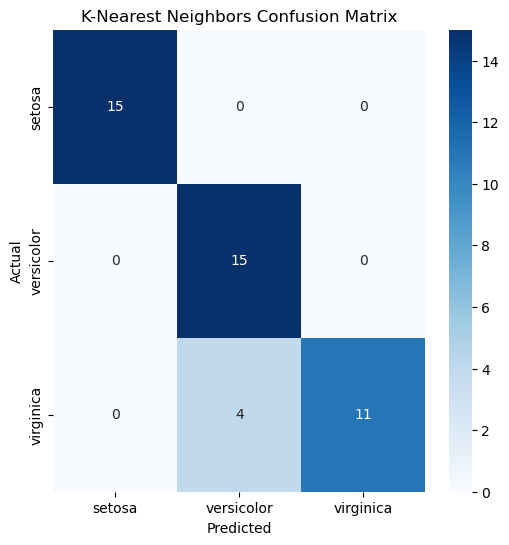


=== Decision Tree Performance ===
Accuracy: 0.91

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.92      0.80      0.86        15
   virginica       0.82      0.93      0.88        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45



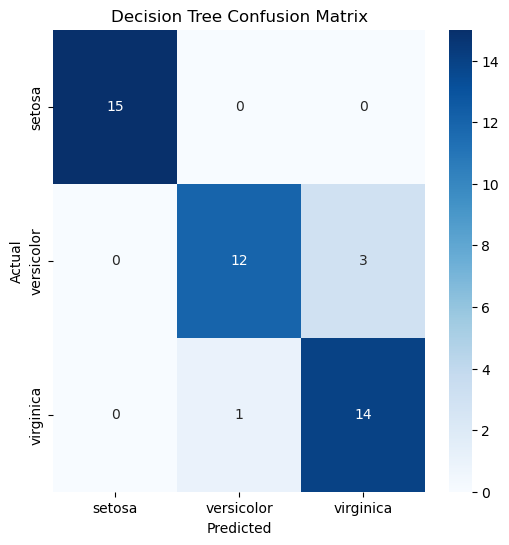


=== Random Forest Performance ===
Accuracy: 0.89

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.78      0.93      0.85        15
   virginica       0.92      0.73      0.81        15

    accuracy                           0.89        45
   macro avg       0.90      0.89      0.89        45
weighted avg       0.90      0.89      0.89        45



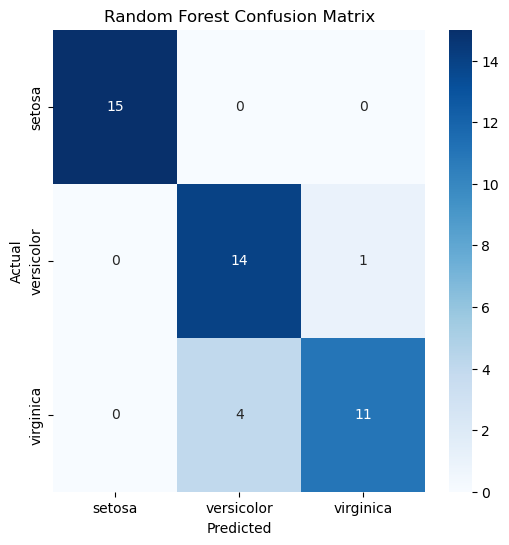

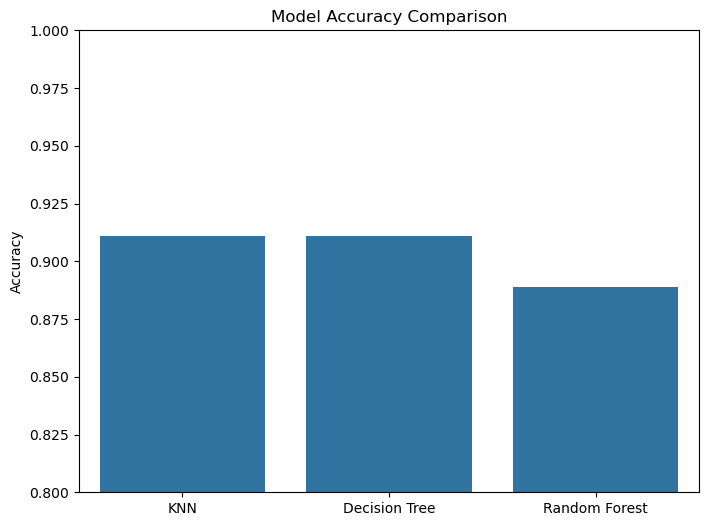


=== Making Predictions ===

Sample Predictions:
Sample 1: Predicted species - setosa
Sample 2: Predicted species - versicolor
Sample 3: Predicted species - virginica


In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Load the Iris dataset
iris = load_iris()
X = iris.data  # Features
y = iris.target  # Target variable (species)

# Feature names
feature_names = iris.feature_names
target_names = iris.target_names

# Create a DataFrame for better visualization
iris_df = pd.DataFrame(X, columns=feature_names)
iris_df['species'] = y
iris_df['species'] = iris_df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

# Data Exploration
print("=== Dataset Overview ===")
print(iris_df.head())
print("\n=== Dataset Information ===")
print(iris_df.info())
print("\n=== Statistical Summary ===")
print(iris_df.describe())
print("\n=== Class Distribution ===")
print(iris_df['species'].value_counts())

# Visualize the data
plt.figure(figsize=(15, 10))

# Pairplot to see relationships between features
sns.pairplot(iris_df, hue='species', markers=['o', 's', 'D'])
plt.suptitle('Pairplot of Iris Features by Species', y=1.02)
plt.show()

# Boxplot for each feature by species
plt.figure(figsize=(15, 8))
for i, feature in enumerate(feature_names):
    plt.subplot(2, 2, i+1)
    sns.boxplot(x='species', y=feature, data=iris_df)
    plt.title(f'Distribution of {feature} by Species')
plt.tight_layout()
plt.show()

# Preprocess the data
# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Model Training and Evaluation
def train_and_evaluate_model(model, model_name):
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Evaluate the model
    accuracy = accuracy_score(y_test, y_pred)
    print(f"\n=== {model_name} Performance ===")
    print(f"Accuracy: {accuracy:.2f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=target_names))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=target_names, yticklabels=target_names)
    plt.title(f'{model_name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    
    return model, accuracy

# Try different models
# 1. K-Nearest Neighbors
knn = KNeighborsClassifier(n_neighbors=3)
knn_model, knn_accuracy = train_and_evaluate_model(knn, "K-Nearest Neighbors")

# 2. Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt_model, dt_accuracy = train_and_evaluate_model(dt, "Decision Tree")

# 3. Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model, rf_accuracy = train_and_evaluate_model(rf, "Random Forest")

# Compare model performances
models = ['KNN', 'Decision Tree', 'Random Forest']
accuracies = [knn_accuracy, dt_accuracy, rf_accuracy]

plt.figure(figsize=(8, 6))
sns.barplot(x=models, y=accuracies)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0.8, 1.0)
plt.show()

# Make predictions with the best model (Random Forest in this case)
print("\n=== Making Predictions ===")
# Sample new data (sepal length, sepal width, petal length, petal width)
new_data = np.array([[5.1, 3.5, 1.4, 0.2],  # setosa
                     [6.5, 3.0, 4.6, 1.3],  # versicolor
                     [7.7, 3.0, 6.1, 2.3]]) # virginica

# Preprocess the new data
new_data_scaled = scaler.transform(new_data)

# Predict
predictions = rf_model.predict(new_data_scaled)

# Display predictions
print("\nSample Predictions:")
for i, pred in enumerate(predictions):
    print(f"Sample {i+1}: Predicted species - {target_names[pred]}")

=== Dataset Overview ===
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  target  
0    3.0  0.0   6.0       0  
1    2.0  3.0   3.0       2  
2    2.0  2.0   7.0       1  
3    3.0  0.0   3.0       0  
4    1.0  0.0   3.0       0  

=== Dataset Information ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3 

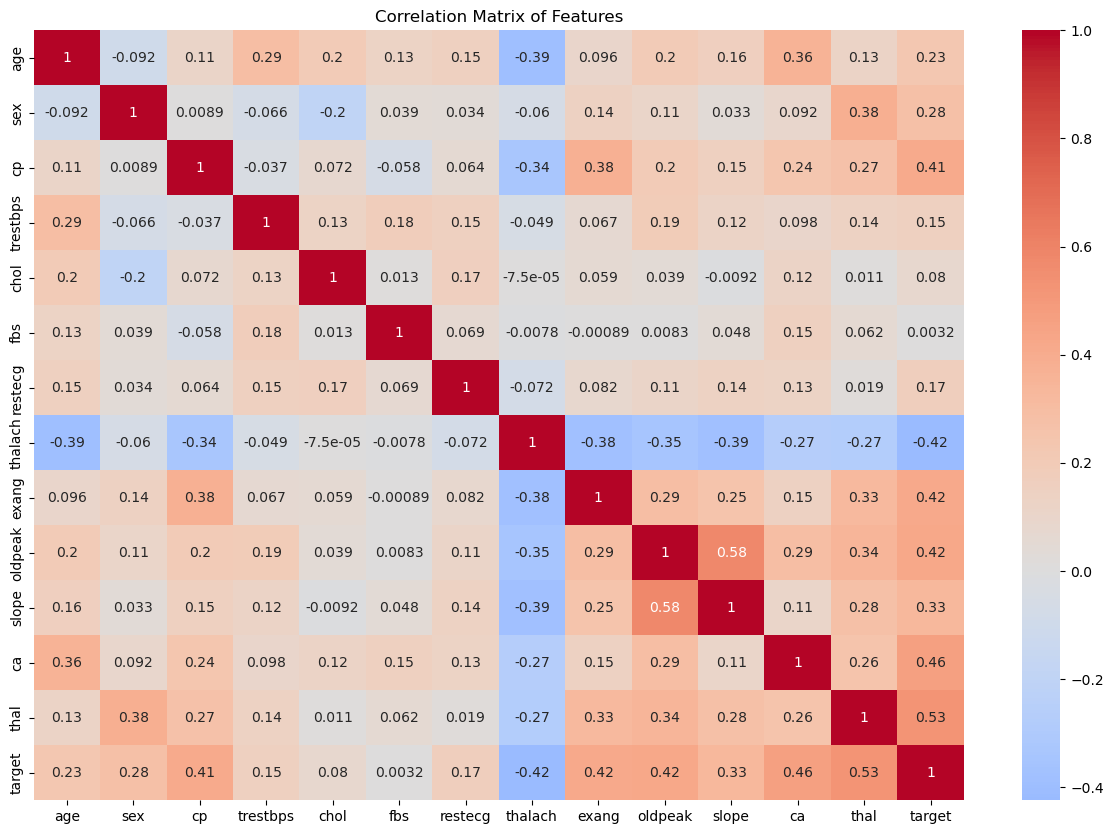

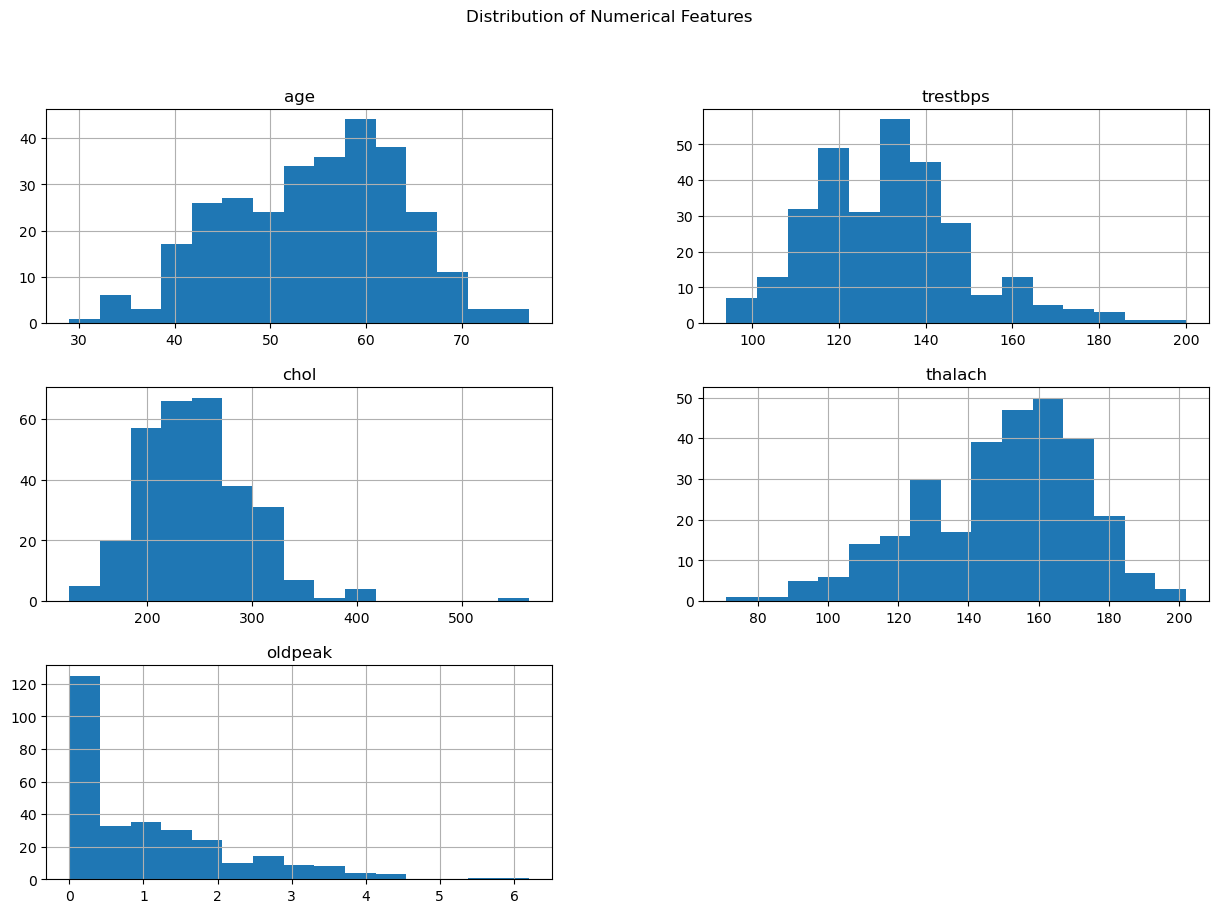

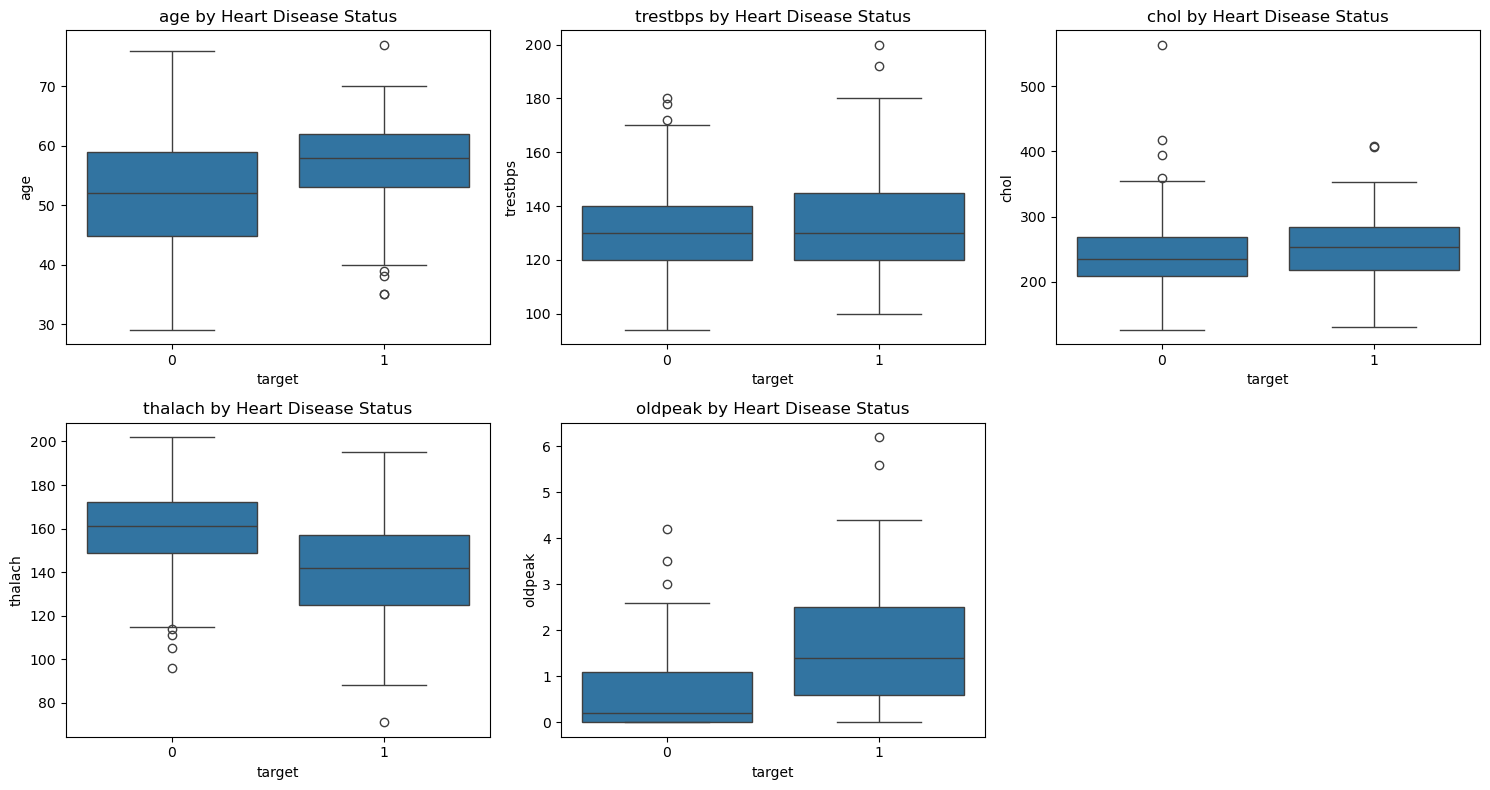

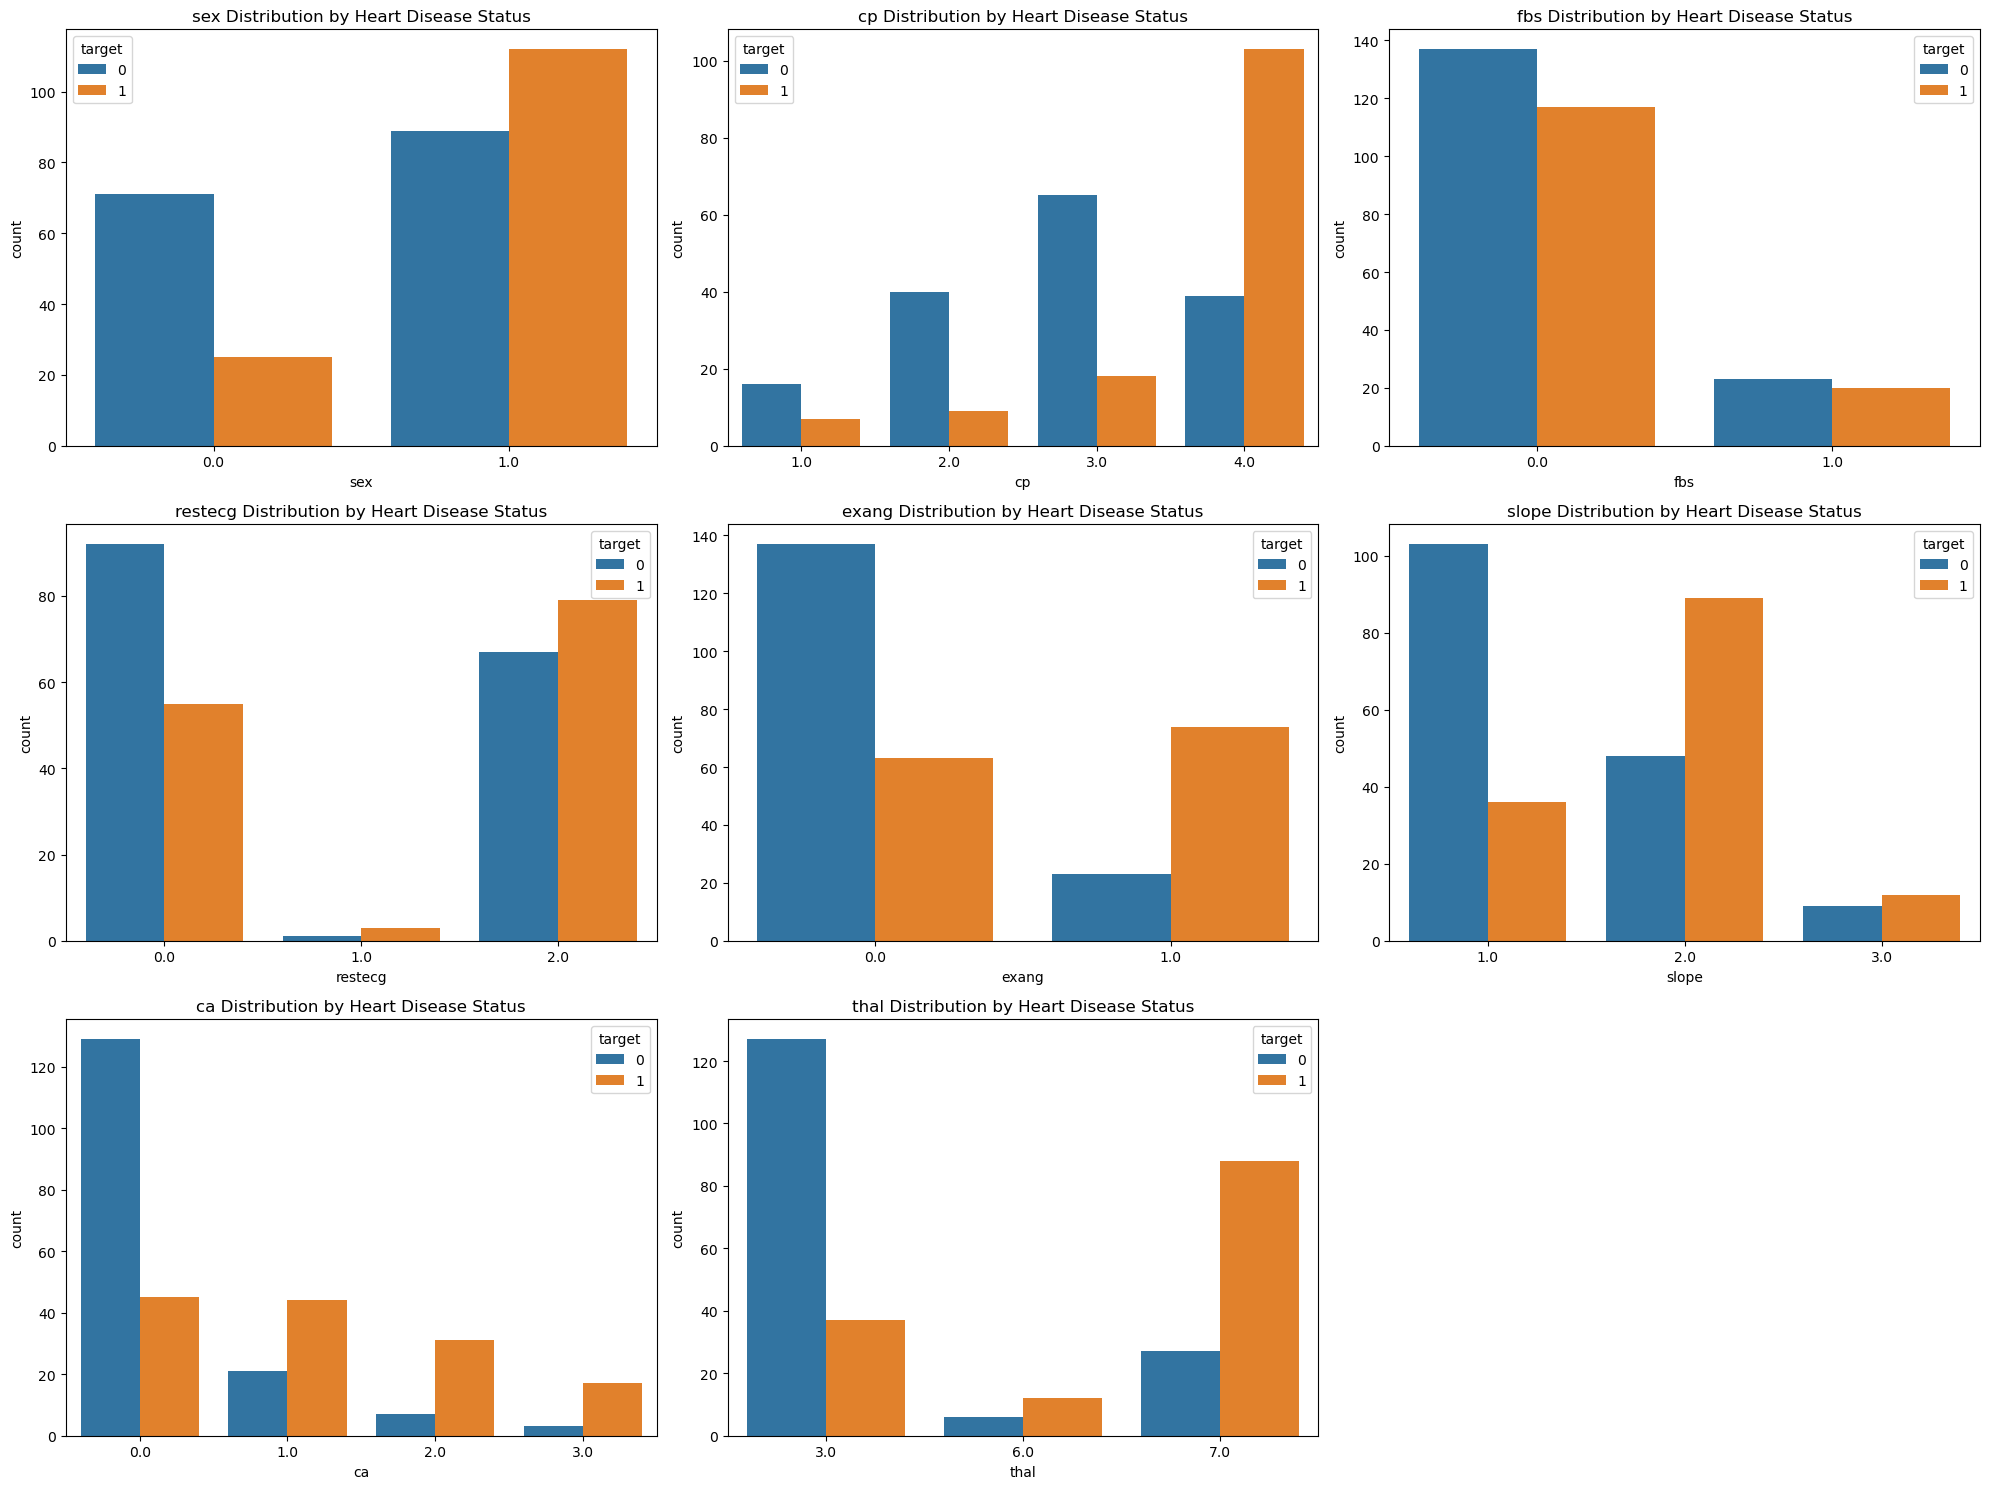


=== Logistic Regression Performance ===
Accuracy: 0.8444
Precision: 0.8684
Recall: 0.7857
F1 Score: 0.8250
ROC AUC: 0.9464

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.90      0.86        48
           1       0.87      0.79      0.82        42

    accuracy                           0.84        90
   macro avg       0.85      0.84      0.84        90
weighted avg       0.85      0.84      0.84        90



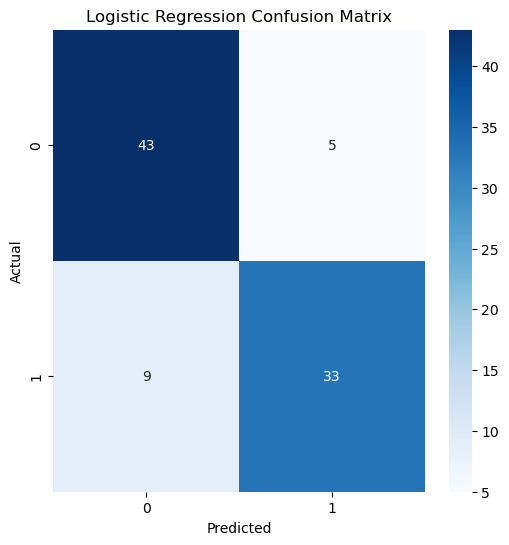

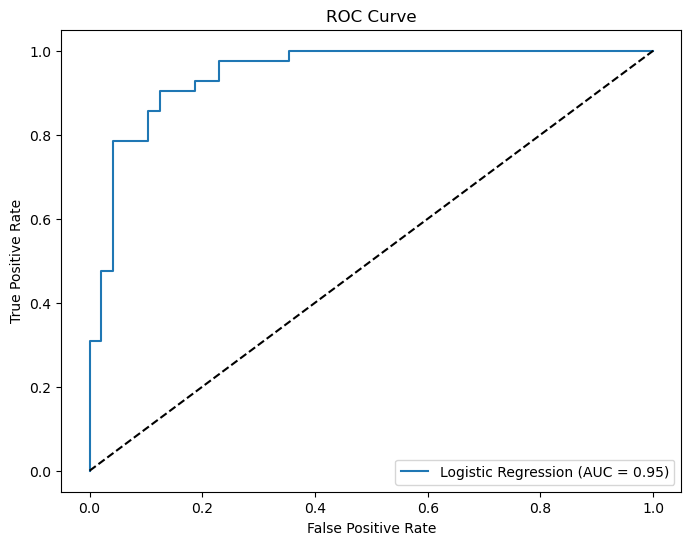


=== K-Nearest Neighbors Performance ===
Accuracy: 0.8222
Precision: 0.8095
Recall: 0.8095
F1 Score: 0.8095
ROC AUC: 0.8844

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.83      0.83        48
           1       0.81      0.81      0.81        42

    accuracy                           0.82        90
   macro avg       0.82      0.82      0.82        90
weighted avg       0.82      0.82      0.82        90



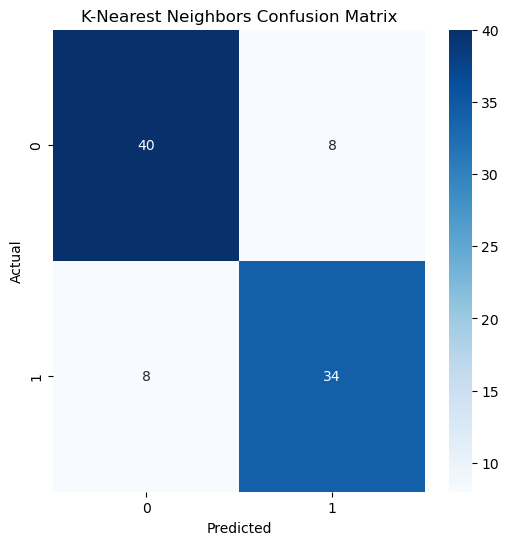

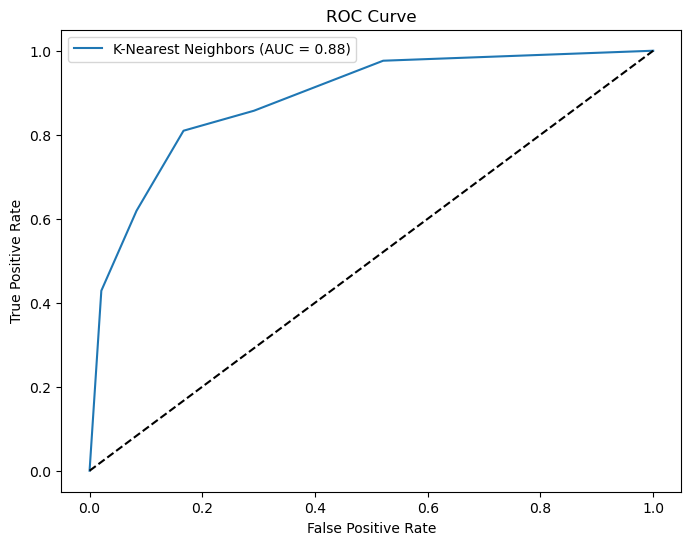


=== Decision Tree Performance ===
Accuracy: 0.7333
Precision: 0.7647
Recall: 0.6190
F1 Score: 0.6842
ROC AUC: 0.7262

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.83      0.77        48
           1       0.76      0.62      0.68        42

    accuracy                           0.73        90
   macro avg       0.74      0.73      0.73        90
weighted avg       0.74      0.73      0.73        90



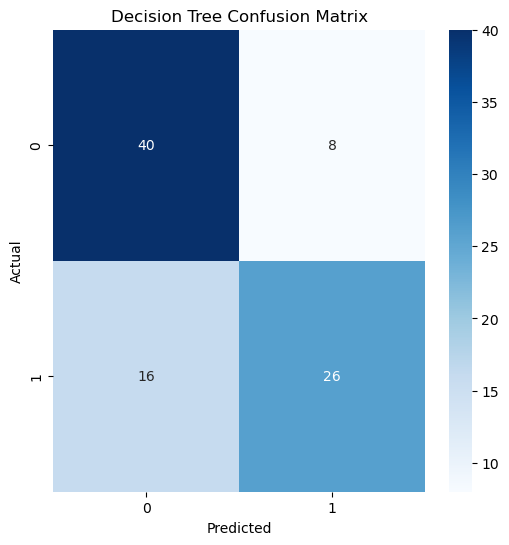

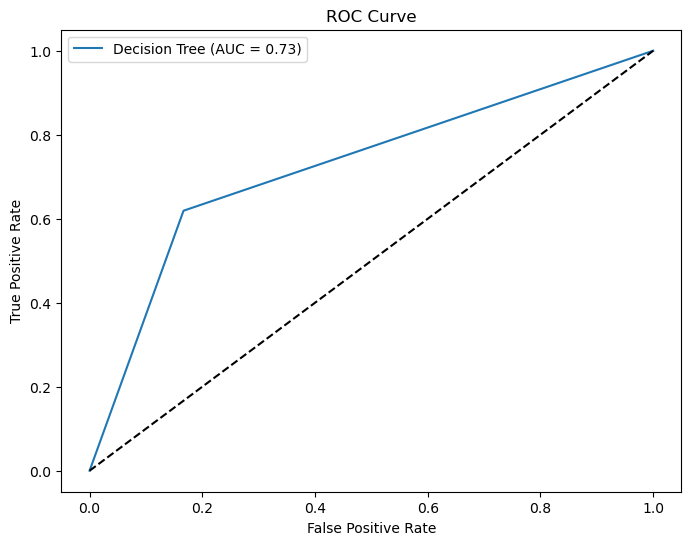


=== Random Forest Performance ===
Accuracy: 0.8556
Precision: 0.8718
Recall: 0.8095
F1 Score: 0.8395
ROC AUC: 0.9293

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87        48
           1       0.87      0.81      0.84        42

    accuracy                           0.86        90
   macro avg       0.86      0.85      0.85        90
weighted avg       0.86      0.86      0.86        90



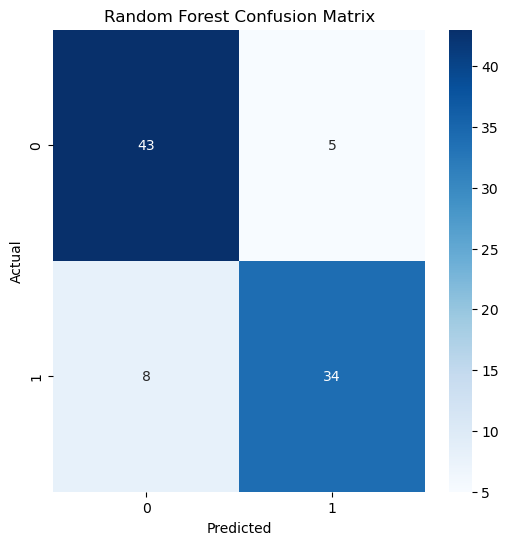

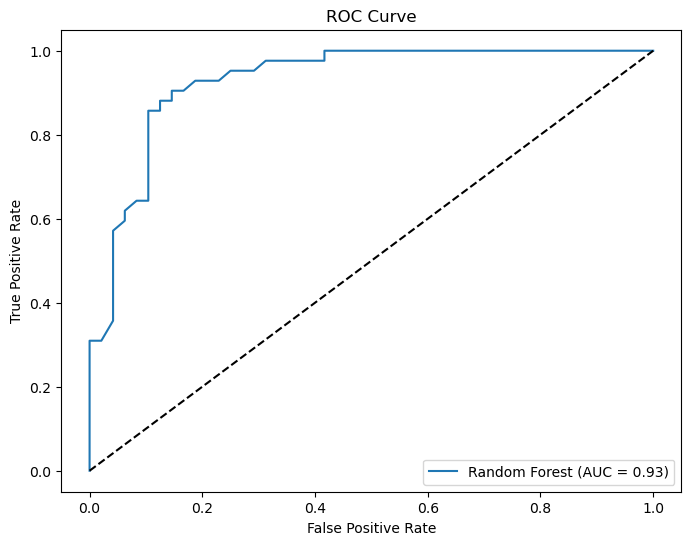


=== Gradient Boosting Performance ===
Accuracy: 0.7778
Precision: 0.8235
Recall: 0.6667
F1 Score: 0.7368
ROC AUC: 0.8775

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.88      0.81        48
           1       0.82      0.67      0.74        42

    accuracy                           0.78        90
   macro avg       0.79      0.77      0.77        90
weighted avg       0.78      0.78      0.77        90



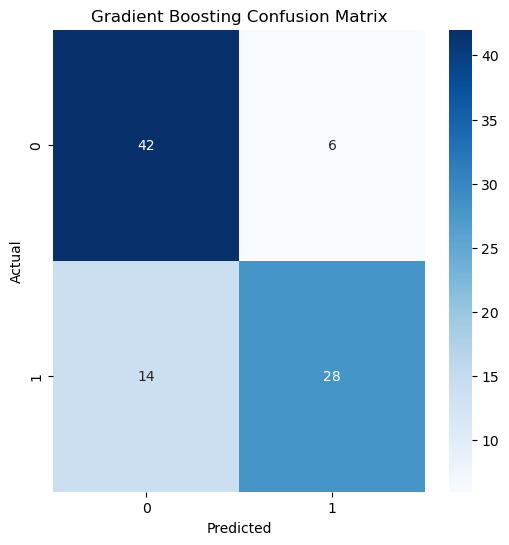

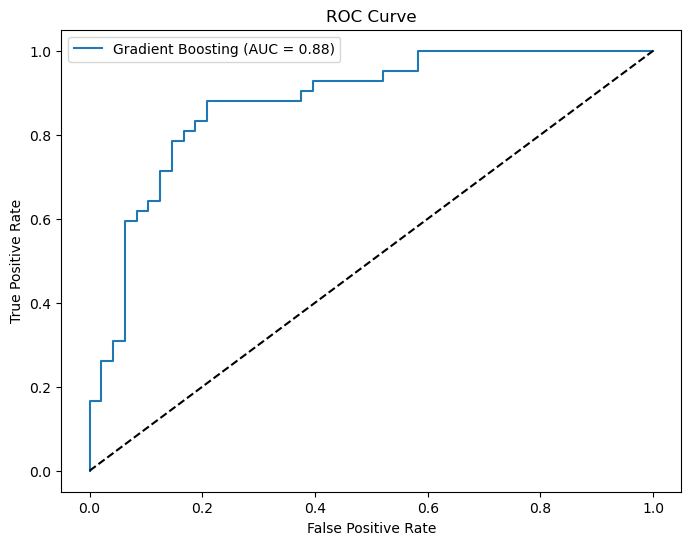


=== Support Vector Machine Performance ===
Accuracy: 0.8556
Precision: 0.8718
Recall: 0.8095
F1 Score: 0.8395
ROC AUC: 0.9261

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87        48
           1       0.87      0.81      0.84        42

    accuracy                           0.86        90
   macro avg       0.86      0.85      0.85        90
weighted avg       0.86      0.86      0.86        90



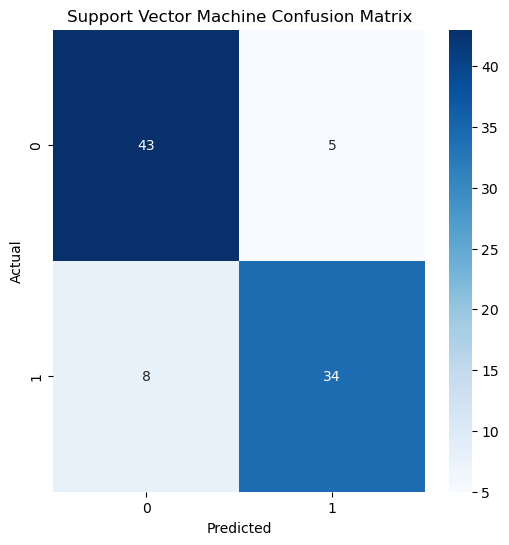

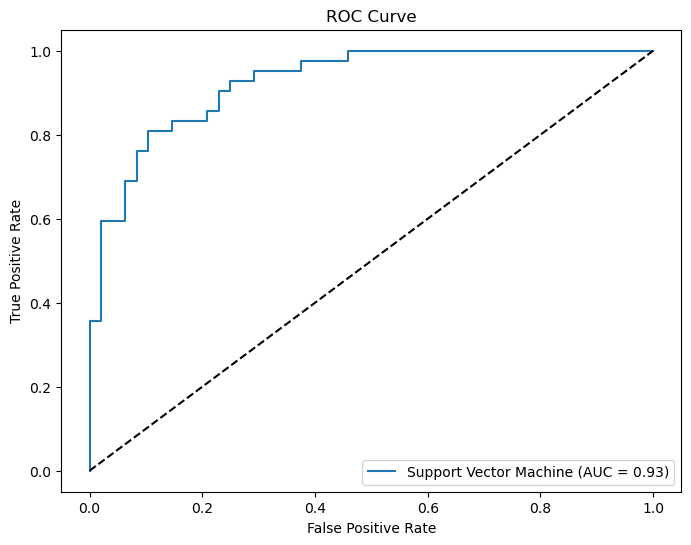


=== Model Performance Comparison ===
                    model  accuracy  precision    recall        f1   roc_auc
3           Random Forest  0.855556   0.871795  0.809524  0.839506  0.929315
5  Support Vector Machine  0.855556   0.871795  0.809524  0.839506  0.926091
0     Logistic Regression  0.844444   0.868421  0.785714  0.825000  0.946429
1     K-Nearest Neighbors  0.822222   0.809524  0.809524  0.809524  0.884425
4       Gradient Boosting  0.777778   0.823529  0.666667  0.736842  0.877480
2           Decision Tree  0.733333   0.764706  0.619048  0.684211  0.726190


C:\Users\asus\AppData\Local\Temp\ipykernel_7880\68567462.py:182: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='accuracy', y='model', data=results_df, palette='viridis')


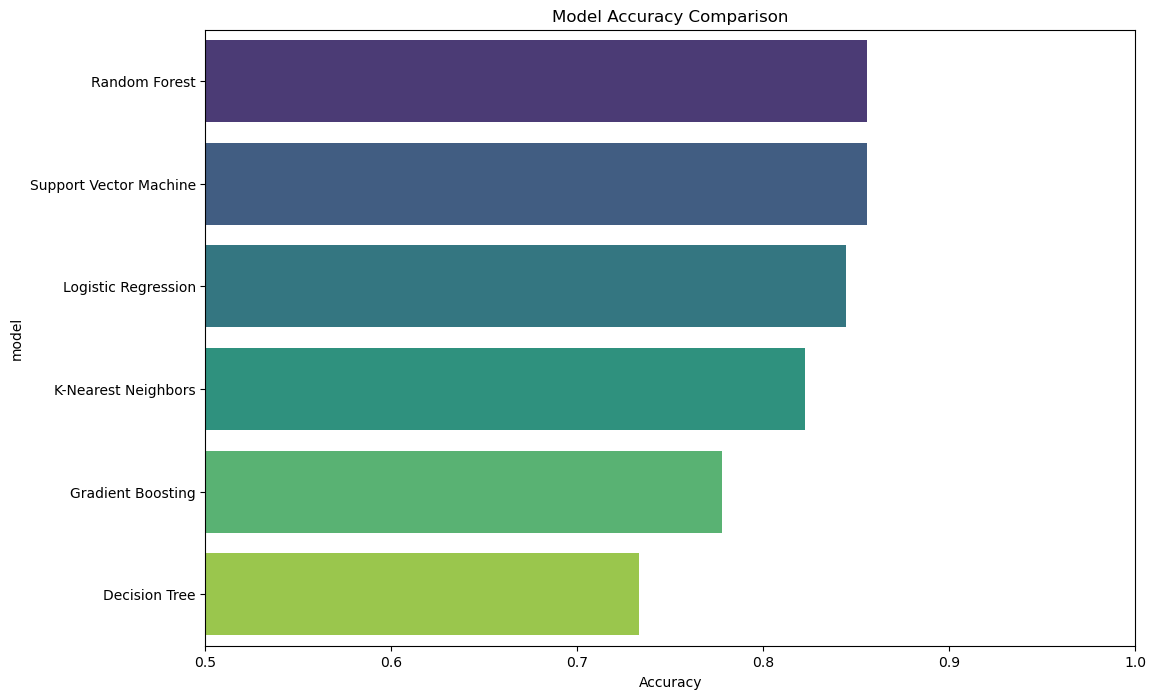

C:\Users\asus\AppData\Local\Temp\ipykernel_7880\68567462.py:198: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importance, palette='viridis')


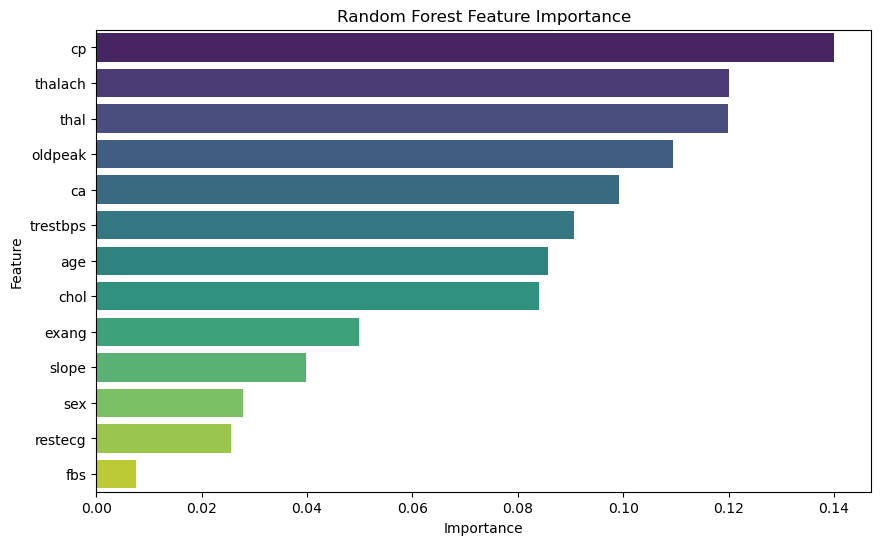


=== Best Parameters ===
{'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}

=== Tuned Random Forest Performance ===
Accuracy: 0.8111
Precision: 0.8571
Recall: 0.7143
F1 Score: 0.7792
ROC AUC: 0.9345

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.90      0.83        48
           1       0.86      0.71      0.78        42

    accuracy                           0.81        90
   macro avg       0.82      0.81      0.81        90
weighted avg       0.82      0.81      0.81        90



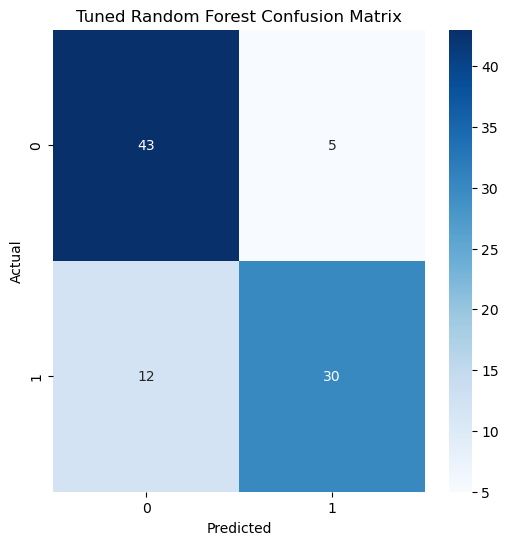

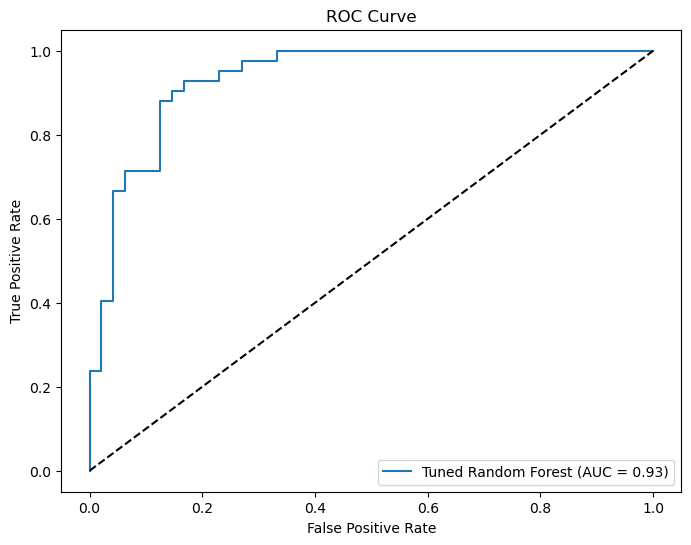


=== Making Predictions ===

Sample Predictions:
Patient 1:
  Prediction: No Heart Disease
  Probability: 7.01%
  Features:
    age: 52.0
    sex: 1.0
    cp: 3.0
    trestbps: 125.0
    chol: 212.0
    fbs: 0.0
    restecg: 1.0
    thalach: 168.0
    exang: 0.0
    oldpeak: 1.0
    slope: 2.0
    ca: 0.0
    thal: 3.0

Patient 2:
  Prediction: Heart Disease
  Probability: 56.09%
  Features:
    age: 63.0
    sex: 1.0
    cp: 1.0
    trestbps: 145.0
    chol: 233.0
    fbs: 1.0
    restecg: 2.0
    thalach: 150.0
    exang: 1.0
    oldpeak: 2.3
    slope: 3.0
    ca: 2.0
    thal: 3.0

Patient 3:
  Prediction: No Heart Disease
  Probability: 15.64%
  Features:
    age: 45.0
    sex: 0.0
    cp: 2.0
    trestbps: 110.0
    chol: 264.0
    fbs: 0.0
    restecg: 0.0
    thalach: 132.0
    exang: 0.0
    oldpeak: 1.2
    slope: 1.0
    ca: 0.0
    thal: 2.0



In [3]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                            f1_score, confusion_matrix, classification_report,
                            roc_auc_score, roc_curve, precision_recall_curve,
                            average_precision_score)

# Set random seed for reproducibility
np.random.seed(42)

# Load the dataset
# Dataset from UCI Machine Learning Repository: https://archive.ics.uci.edu/ml/datasets/Heart+Disease
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
column_names = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'
]
heart_df = pd.read_csv(url, names=column_names, na_values='?')

# Data Exploration
print("=== Dataset Overview ===")
print(heart_df.head())
print("\n=== Dataset Information ===")
print(heart_df.info())
print("\n=== Statistical Summary ===")
print(heart_df.describe())
print("\n=== Missing Values ===")
print(heart_df.isnull().sum())

# Handle missing values
# For simplicity, we'll drop rows with missing values (only a few in this dataset)
heart_df = heart_df.dropna()

# Convert target to binary (0 = no disease, 1 = disease)
heart_df['target'] = heart_df['target'].apply(lambda x: 1 if x > 0 else 0)

# Check class distribution
print("\n=== Target Class Distribution ===")
print(heart_df['target'].value_counts(normalize=True))

# Visualize the data
plt.figure(figsize=(15, 10))

# Correlation matrix
corr_matrix = heart_df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Features')
plt.show()

# Distribution of numerical features
numerical_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
heart_df[numerical_features].hist(bins=15, figsize=(15, 10))
plt.suptitle('Distribution of Numerical Features')
plt.show()

# Boxplots for numerical features by target
plt.figure(figsize=(15, 8))
for i, feature in enumerate(numerical_features):
    plt.subplot(2, 3, i+1)
    sns.boxplot(x='target', y=feature, data=heart_df)
    plt.title(f'{feature} by Heart Disease Status')
plt.tight_layout()
plt.show()

# Count plots for categorical features
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
plt.figure(figsize=(20, 15))
for i, feature in enumerate(categorical_features):
    plt.subplot(3, 3, i+1)
    sns.countplot(x=feature, hue='target', data=heart_df)
    plt.title(f'{feature} Distribution by Heart Disease Status')
plt.tight_layout()
plt.show()

# Data Preprocessing
# Separate features and target
X = heart_df.drop('target', axis=1)
y = heart_df['target']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Standardize numerical features
scaler = StandardScaler()
X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test[numerical_features] = scaler.transform(X_test[numerical_features])

# Model Training and Evaluation
def train_and_evaluate_model(model, model_name, X_train, y_train, X_test, y_test):
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else None
    
    # Print evaluation metrics
    print(f"\n=== {model_name} Performance ===")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    if roc_auc is not None:
        print(f"ROC AUC: {roc_auc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{model_name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    
    # ROC Curve (if probabilities are available)
    if y_pred_proba is not None:
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve')
        plt.legend()
        plt.show()
    
    return {
        'model': model_name,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc
    }

# Initialize models
models = [
    ('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42)),
    ('K-Nearest Neighbors', KNeighborsClassifier()),
    ('Decision Tree', DecisionTreeClassifier(random_state=42)),
    ('Random Forest', RandomForestClassifier(random_state=42)),
    ('Gradient Boosting', GradientBoostingClassifier(random_state=42)),
    ('Support Vector Machine', SVC(probability=True, random_state=42))
]

# Train and evaluate all models
results = []
for name, model in models:
    result = train_and_evaluate_model(model, name, X_train, y_train, X_test, y_test)
    results.append(result)

# Compare model performances
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('accuracy', ascending=False)

print("\n=== Model Performance Comparison ===")
print(results_df)

# Visualize model comparison
plt.figure(figsize=(12, 8))
sns.barplot(x='accuracy', y='model', data=results_df, palette='viridis')
plt.title('Model Accuracy Comparison')
plt.xlabel('Accuracy')
plt.xlim(0.5, 1.0)
plt.show()

# Feature Importance for the best model (Random Forest)
best_model = RandomForestClassifier(random_state=42)
best_model.fit(X_train, y_train)

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importance, palette='viridis')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

# Hyperparameter Tuning for the best model (Random Forest)
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("\n=== Best Parameters ===")
print(grid_search.best_params_)

# Evaluate the tuned model
best_rf = grid_search.best_estimator_
train_and_evaluate_model(best_rf, "Tuned Random Forest", X_train, y_train, X_test, y_test)

# Make predictions with the best model
print("\n=== Making Predictions ===")
# Sample new data (using values from the dataset)
sample_data = {
    'age': [52, 63, 45],
    'sex': [1, 1, 0],  # 1 = male, 0 = female
    'cp': [3, 1, 2],  # chest pain type (1-4)
    'trestbps': [125, 145, 110],  # resting blood pressure
    'chol': [212, 233, 264],  # serum cholesterol
    'fbs': [0, 1, 0],  # fasting blood sugar > 120 mg/dl
    'restecg': [1, 2, 0],  # resting electrocardiographic results
    'thalach': [168, 150, 132],  # maximum heart rate achieved
    'exang': [0, 1, 0],  # exercise induced angina
    'oldpeak': [1.0, 2.3, 1.2],  # ST depression induced by exercise
    'slope': [2, 3, 1],  # slope of peak exercise ST segment
    'ca': [0, 2, 0],  # number of major vessels colored by fluoroscopy
    'thal': [3, 3, 2]  # thalassemia (3 = normal, 6 = fixed defect, 7 = reversible defect)
}

sample_df = pd.DataFrame(sample_data)
sample_df_scaled = sample_df.copy()
sample_df_scaled[numerical_features] = scaler.transform(sample_df[numerical_features])

# Predict
predictions = best_rf.predict(sample_df_scaled)
prediction_probs = best_rf.predict_proba(sample_df_scaled)[:, 1]

# Display predictions
print("\nSample Predictions:")
for i, (pred, prob) in enumerate(zip(predictions, prediction_probs)):
    status = "Heart Disease" if pred == 1 else "No Heart Disease"
    print(f"Patient {i+1}:")
    print(f"  Prediction: {status}")
    print(f"  Probability: {prob:.2%}")
    print("  Features:")
    for col, val in sample_df.iloc[i].items():
        print(f"    {col}: {val}")
    print()

In [5]:
a=33
b=4.5
a+b

37.5

In [7]:
a-b

28.5

In [9]:
a%b

1.5

In [11]:
a**b

6812597.478345025

In [13]:
a*b

148.5

In [15]:
a

33

In [17]:
b

4.5

In [19]:
b+a

37.5

In [21]:
b-a

-28.5

In [23]:
b*a

148.5

In [25]:
b**a

3.5976006629216265e+21

In [27]:
b%a

4.5

In [29]:
b+a

37.5

In [31]:
b-a

-28.5